# Laboratorio #7: FPGrowth Trees

## Dataset

El algoritmos de reglas de asociación (FP-Growth) funciona con transacciones categóricas, no numéricas. Por lo que, se crea una función para transformar cada porcentaje en 3 categorías y se convierte a formato binario que requiere el algoritmo.

In [16]:
import pandas as pd
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Cargar dataset como archivo .csv
nutr = pd.read_csv('Comprehensive National Nutrition Survey (CNNS) 2016-18  Key Anthropometric Indicators by Sex.csv')

# 5 primeras filas
# nutr.head()

# Preprocesado de datos
# Renombrar columnas largas para simplificar
nutr = nutr.rename(columns={
    'Gender': 'Gender',
    'Stunted (height for age) children under the age of 5 years (%)': 'Stunted_U5',
    'Severely stunted (height for age) children under the age of 5 years (%)': 'Severe_Stunted_U5',
    'Moderate or severely thin adolescents age group 10 to19 years with ( body mass index ( bmi ) for age) z-score less than -2 sd (%)': 'Thin_10_19',
    'Overweight or obese adolescents age group 10 to 19 years with ( body mass index ( bmi ) for age ) z-score greater than +1 sd (%)': 'Overweight_10_19',
    'Obese adolescents age group 10 to 19 years with ( body mass index ( bmi ) for age ) z-score greater than +2 sd (%)': 'Obese_10_19'
})

# Seleccionar columnas clave
df = nutr[['Gender', 'Stunted_U5', 'Severe_Stunted_U5', 'Thin_10_19', 'Overweight_10_19', 'Obese_10_19']].dropna()

def categorize_pct(x):
    if x < 10:
        return 'bajo'
    elif x < 25:
        return 'medio'
    else:
        return 'alto'

# Aplicar categorización
df['Stunted_U5_cat'] = df['Stunted_U5'].apply(categorize_pct)
df['Severe_Stunted_U5_cat'] = df['Severe_Stunted_U5'].apply(categorize_pct)
df['Thin_10_19_cat'] = df['Thin_10_19'].apply(categorize_pct)
df['Overweight_10_19_cat'] = df['Overweight_10_19'].apply(categorize_pct)
df['Obese_10_19_cat'] = df['Obese_10_19'].apply(categorize_pct)

# Combinar como transacciones
records = df.apply(lambda row: [
    f"Gender={row['Gender']}",
    f"Stunted_U5={row['Stunted_U5_cat']}",
    f"Severe_Stunted_U5={row['Severe_Stunted_U5_cat']}",
    f"Thin_10_19={row['Thin_10_19_cat']}",
    f"Overweight_10_19={row['Overweight_10_19_cat']}",
    f"Obese_10_19={row['Obese_10_19_cat']}"
], axis=1).tolist()

# Transformar a one-hot
te = TransactionEncoder()
te_ary = te.fit(records).transform(records)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)
df_encoded.head()

,Gender=Female,Gender=Male,Obese_10_19=bajo,Overweight_10_19=bajo,Overweight_10_19=medio,Severe_Stunted_U5=bajo,Severe_Stunted_U5=medio,Stunted_U5=alto,Stunted_U5=medio,Thin_10_19=alto,Thin_10_19=bajo,Thin_10_19=medio
0,True,False,True,True,False,True,False,False,True,False,False,True
1,False,True,True,True,False,True,False,False,True,False,False,True
2,True,False,True,True,False,True,False,False,True,True,False,False
3,False,True,True,True,False,True,False,True,False,True,False,False
4,True,False,True,True,False,True,False,False,True,False,False,True


## Técnica para reglas de asociación

Se encuentran los conjuntos frecuentes de ítems, combinaciones de atributos que ocurren juntas con cierta frecuencia. Por medio del conjunto de items frecuentes, se encuentran y generan las reglas de asociación.

In [27]:
# Generar itemsets frecuentes
frequent_itemsets = fpgrowth(df_encoded, min_support=0.1, use_colnames=True)

# Reglas con confianza mínima de 60%
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)
# print(rules.columns)

# Mantener medidas clave
rules = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'conviction', 'kulczynski', 'consequent support']]
rules.head()

/usr/local/lib/python3.11/dist-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


,antecedents,consequents,support,confidence,lift,conviction,kulczynski,consequent support
0,(Overweight_10_19=bajo),(Obese_10_19=bajo),0.838710,1.000000,1.000000,inf,0.919355,1.000000
1,(Obese_10_19=bajo),(Overweight_10_19=bajo),0.838710,0.838710,1.000000,1.000000,0.919355,0.838710
2,(Thin_10_19=medio),(Obese_10_19=bajo),0.629032,1.000000,1.000000,inf,0.814516,1.000000
3,(Obese_10_19=bajo),(Thin_10_19=medio),0.629032,0.629032,1.000000,1.000000,0.814516,0.629032
4,(Overweight_10_19=bajo),(Thin_10_19=medio),0.516129,0.615385,0.978304,0.964516,0.717949,0.629032


## Selección de la medida

Se utiliza otra medida (kulczynski) para identificar los patrones fuertes.

In [30]:
print("Reglas con mayor confianza (sin medidas extra):")
print(rules.sort_values(by='confidence', ascending=False).head(5))

rules['kulczynski'] = 0.5 * (
    rules['confidence'] +
    rules['support'] / rules['consequent support']
)

rules_kulc = rules[rules['kulczynski'] >= 0.8]

Reglas con mayor confianza (sin medidas extra):
                                           antecedents  \
705                                  (Thin_10_19=bajo)   
7            (Overweight_10_19=bajo, Thin_10_19=medio)   
289  (Thin_10_19=medio, Overweight_10_19=bajo, Stun...   
287  (Overweight_10_19=bajo, Stunted_U5=medio, Thin...   
247                                 (Stunted_U5=medio)   

                                    consequents   support  confidence  \
705                          (Obese_10_19=bajo)  0.145161         1.0   
7                            (Obese_10_19=bajo)  0.516129         1.0   
289                          (Obese_10_19=bajo)  0.129032         1.0   
287                    (Severe_Stunted_U5=bajo)  0.129032         1.0   
247  (Severe_Stunted_U5=bajo, Obese_10_19=bajo)  0.241935         1.0   

         lift  conviction  kulczynski  consequent support  
705  1.000000         inf    0.572581            1.000000  
7    1.000000         inf    0.758065       

## Patrones interesantes

Detección de los patrones interesentantes. Comparación de los patrones con y sin la medida de kulczynski.


In [35]:
rules_confident = rules[rules['confidence'] >= 0.8]
rules_kulc = rules[rules['kulczynski'] >= 0.8]

print("Reglas con confianza alta solamente:", len(rules_confident))
print("Reglas con Kulczynski alto:", len(rules_kulc))

# Reglas que son fuertes en ambos
common = pd.merge(rules_confident, rules_kulc, how='inner', on=['antecedents', 'consequents'])
print("Reglas fuertes en ambos casos:", len(common))

# Reglas con confianza alta pero Kulc bajo
misleading = rules_confident[~rules_confident.set_index(['antecedents', 'consequents']).index.isin(
    rules_kulc.set_index(['antecedents', 'consequents']).index
)]
print("⚠️ Reglas engañosas (confianza alta pero Kulc bajo):", len(misleading))


# Filtrar reglas interesantes fuertes
rules_interesting = rules[(rules['confidence'] >= 0.8) & (rules['kulczynski'] >= 0.8)]

# Mostrar las primeras 10 reglas interesantes
print("\n\nReglas interesantes fuertes:")
print(rules_interesting[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'conviction', 'kulczynski']].head(10))


# Mostrar las reglas engañosas (confianza alta pero Kulczynski bajo)
rules_misleading = rules[(rules['confidence'] >= 0.8) & (rules['kulczynski'] < 0.8)]

print("\n\nReglas engañosas (alta confianza pero Kulczynski bajo):")
print(rules_misleading[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'conviction', 'kulczynski']].head(10))

Reglas con confianza alta solamente: 424
Reglas con Kulczynski alto: 32
Reglas fuertes en ambos casos: 20
⚠️ Reglas engañosas (confianza alta pero Kulc bajo): 404


Reglas interesantes fuertes:
                                   antecedents  \
0                      (Overweight_10_19=bajo)   
1                           (Obese_10_19=bajo)   
2                           (Thin_10_19=medio)   
630                          (Stunted_U5=alto)   
632                    (Overweight_10_19=bajo)   
633                          (Stunted_U5=alto)   
634   (Overweight_10_19=bajo, Stunted_U5=alto)   
635  (Overweight_10_19=bajo, Obese_10_19=bajo)   
636        (Stunted_U5=alto, Obese_10_19=bajo)   
637                    (Overweight_10_19=bajo)   

                             consequents   support  confidence      lift  \
0                     (Obese_10_19=bajo)  0.838710    1.000000  1.000000   
1                (Overweight_10_19=bajo)  0.838710    0.838710  1.000000   
2                     (Obes

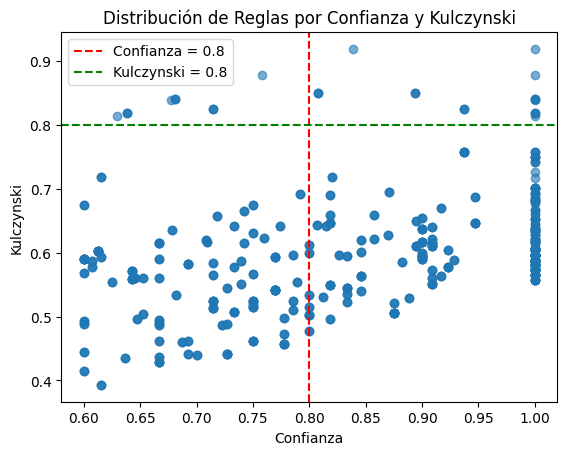

In [36]:
import matplotlib.pyplot as plt

plt.scatter(rules['confidence'], rules['kulczynski'], alpha=0.6)
plt.axvline(0.8, color='red', linestyle='--', label='Confianza = 0.8')
plt.axhline(0.8, color='green', linestyle='--', label='Kulczynski = 0.8')
plt.xlabel('Confianza')
plt.ylabel('Kulczynski')
plt.title('Distribución de Reglas por Confianza y Kulczynski')
plt.legend()
plt.show()

#### Comparación

- Reglas fuertes reales: aparecerán tanto con confidence alta como con kulczynski alto.

- Reglas engañosas: podrían tener confidence alta, pero kulczynski bajo, esto significa que la relación no es recíproca o es asimétrica.

- Kulczynski ayuda a evitar reglas que parecen fuertes pero solo en una dirección.